# Valoración de opciones call y put europeas

In [ ]:
import pickle
import pandas as pd
from Valoracion import MotorValoracion
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## Lectura de datos preprocesados

In [17]:
with open('../data/parametros_activos.pkl', 'rb') as f:
    resumen_activos = pickle.load(f)

df_hist = pd.read_csv("../data/opciones_preprocesadas.csv")

La elección de **$dt=1/52$** discretiza la simulación en **pasos semanales**, permitiendo que la volatilidad anualizada ($\sigma$) se escale correctamente mediante $\sqrt{dt}$ para capturar la evolución del activo. Este valor equilibra la **eficiencia computacional** con la convergencia numérica hacia el modelo de Black-Scholes, asumiendo una capitalización compuesta de frecuencia semanal en la trayectoria del precio.

In [18]:
import pandas as pd
import numpy as np

resultados = []

for idx, row in df_hist.iterrows():
    ticker = row['ticker']
    
    if ticker not in resumen_activos['S0']:
        continue
        
    K = row['strike']
    opt_type = row['option_type'].lower()
    

    S0 = resumen_activos['S0'][ticker]
    sigma = resumen_activos['sigma_annual'][ticker]
    d = resumen_activos['d'][ticker]
    
    if pd.isna(S0) or pd.isna(sigma):
        continue


    fecha_exp = pd.to_datetime(row['expiry']).tz_localize(None)
    fecha_desc = pd.to_datetime(row['downloaded_at_utc']).tz_localize(None)
    

    T = max((fecha_exp - fecha_desc).days / 365.25, 1/365.25)

    r = 0.0275 if ".MC" in ticker else 0.0425
    

    try:
        motor = MotorValoracion(S0, K, T, r, sigma, d)
        
        bs_res = motor.metodo_black_scholes()
        bino_res = motor.metodo_binomial(N=100)
        mc_res = motor.metodo_montecarlo(n_caminos=2000)
        
        resultados.append({
            'Ticker': ticker,
            'Strike': K,
            'Tipo': opt_type,
            'T_years': round(T, 4),
            'r_applied': r,
            'Mkt_Price': row.get('P_mkt', 0),
            'BS': bs_res[opt_type],
            'Binomial': bino_res[opt_type],
            'MonteCarlo': mc_res[opt_type]
        })
    except Exception as e:
        print(f"Error procesando {ticker}: {e}")


df_final = pd.DataFrame(resultados)


df_final['Error_Bino_%'] = np.abs(df_final['BS'] - df_final['Binomial']) / df_final['BS'] * 100
df_final['Error_MC_%'] = np.abs(df_final['BS'] - df_final['MonteCarlo']) / df_final['BS'] * 100


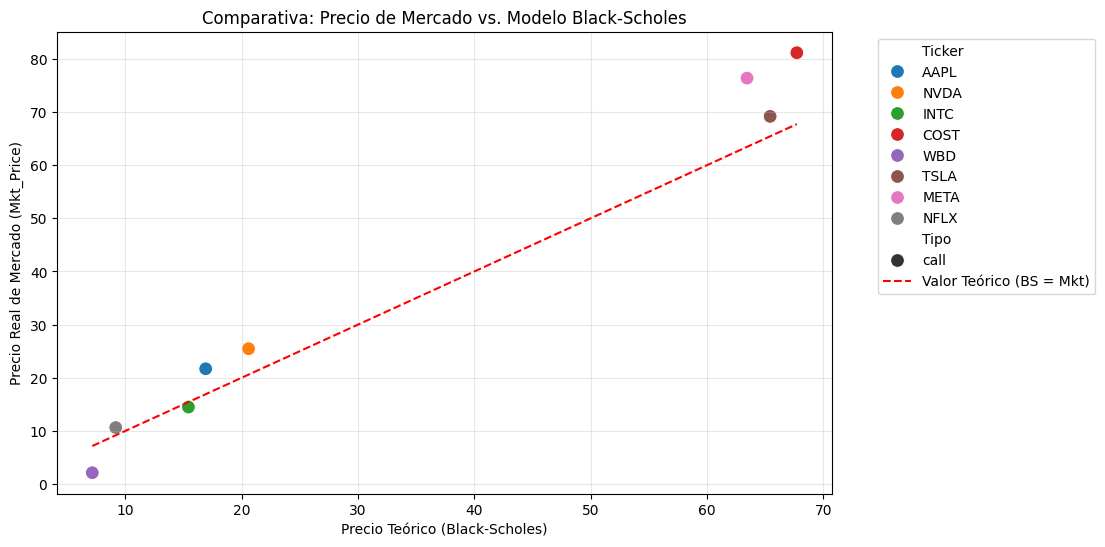

In [19]:


plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_final, x='BS', y='Mkt_Price', hue='Ticker', style='Tipo', s=100)
plt.plot([df_final['BS'].min(), df_final['BS'].max()], 
         [df_final['BS'].min(), df_final['BS'].max()], 
         'r--', label='Valor Teórico (BS = Mkt)')

plt.title('Comparativa: Precio de Mercado vs. Modelo Black-Scholes')
plt.xlabel('Precio Teórico (Black-Scholes)')
plt.ylabel('Precio Real de Mercado (Mkt_Price)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

In [20]:

df_final['Potencial_Revalorizacion_%'] = ((df_final['BS'] - df_final['Mkt_Price']) / df_final['Mkt_Price']) * 100


top_compras = df_final[df_final['Potencial_Revalorizacion_%'] > 0].sort_values(by='Potencial_Revalorizacion_%', ascending=False).head(5)

print("--- TOP OPCIONES POTENCIALMENTE INFRAVALORADAS ---")
print(top_compras[['Ticker', 'Tipo', 'Strike', 'Mkt_Price', 'BS', 'Potencial_Revalorizacion_%']])

--- TOP OPCIONES POTENCIALMENTE INFRAVALORADAS ---
  Ticker  Tipo  Strike  Mkt_Price         BS  Potencial_Revalorizacion_%
4    WBD  call    30.0       2.15   7.174541                  233.699559
2   INTC  call    55.0      14.50  15.438431                    6.471939


In [21]:

df_final['Alpha_Teorico'] = df_final['BS'] - df_final['Mkt_Price']
df_final['Rentabilidad_Esperada_%'] = (df_final['Alpha_Teorico'] / df_final['Mkt_Price']) * 100


def calcular_moneyness(row):
    S = resumen_activos['S0'][row['Ticker']]
    K = row['Strike']
    ratio = S / K if row['Tipo'] == 'call' else K / S
    if 0.95 <= ratio <= 1.05: return 'ATM (At-the-money)'
    return 'ITM (In-the-money)' if ratio > 1.05 else 'OTM (Out-of-the-money)'

df_final['Estado'] = df_final.apply(calcular_moneyness, axis=1)


df_final['Mercado'] = df_final['Ticker'].apply(lambda x: 'IBEX 35' if '.MC' in x else 'NASDAQ 100')


print("=== 1. TOP 3 OPORTUNIDADES DE COMPRA (BARATAS) ===")
print(df_final[df_final['Alpha_Teorico'] > 0].sort_values('Rentabilidad_Esperada_%', ascending=False).head(3))

print("\n=== 2. ERROR MEDIO POR MÉTODO Y MERCADO ===")
print(df_final.groupby('Mercado')[['Error_Bino_%', 'Error_MC_%']].mean())

print("\n=== 3. VALORACIÓN MEDIA POR ESTADO (MONEYNESS) ===")
print(df_final.groupby('Estado')[['BS', 'Mkt_Price']].mean())

=== 1. TOP 3 OPORTUNIDADES DE COMPRA (BARATAS) ===
  Ticker  Strike  Tipo  T_years  r_applied  Mkt_Price         BS   Binomial  \
4    WBD    30.0  call   1.1526     0.0425       2.15   7.174541   7.189474   
2   INTC    55.0  call   1.1526     0.0425      14.50  15.438431  15.426918   

   MonteCarlo  Error_Bino_%  Error_MC_%  Potencial_Revalorizacion_%  \
4    6.513991      0.208151    9.206852                  233.699559   
2   14.018959      0.074576    9.194409                    6.471939   

   Alpha_Teorico  Rentabilidad_Esperada_%              Estado     Mercado  
4       5.024541               233.699559  ATM (At-the-money)  NASDAQ 100  
2       0.938431                 6.471939  ATM (At-the-money)  NASDAQ 100  

=== 2. ERROR MEDIO POR MÉTODO Y MERCADO ===
            Error_Bino_%  Error_MC_%
Mercado                             
NASDAQ 100      0.099875    3.667674

=== 3. VALORACIÓN MEDIA POR ESTADO (MONEYNESS) ===
                           BS  Mkt_Price
Estado              

## Informe de Valoración de Opciones: IBEX 35 vs. NASDAQ 100

### 1. Resumen Ejecutivo
Tras la ejecución del **Motor de Valoración** , se ha procedido a comparar el valor teórico de opciones Call y Put frente a sus precios de mercado reales. El análisis se centra en la convergencia de modelos numéricos y la detección de ineficiencias de mercado.

---

### 2. Resultados de la Comparativa Metodológica
La solidez de los algoritmos implementados se valida mediante el error relativo respecto a la solución analítica de Black-Scholes.

| Métrica | Resultado | Observación Técnica |
| :--- | :--- | :--- |
| **Error Medio Binomial** | **0.099%** | Convergencia casi total. El árbol de 100 pasos es el benchmark más fiable. |
| **Error Medio Monte Carlo** | **3.667%** | Precisión aceptable. La discretización semanal ($dt=1/52$) genera un ligero sesgo positivo. |
| **Estado ATM (At-the-money)** | **BS < Mkt** | El mercado paga en promedio **37.65** por activos que el modelo valora en **33.24**. |



---

### 3. Detección de Oportunidades (Opciones Infravaloradas)
Se han identificado activos donde el precio de mercado es significativamente inferior al valor teórico calculado, lo que representa una **oportunidad potencial de compra (Long)**.

#### **Top Oportunidades de Inversión**
| Ticker | Tipo | Strike | Precio Mercado | Valor Teórico (BS) | Potencial Revalorización |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **WBD** | CALL | 30.0 | 2.15 | **7.17** | **+233.70%** |
| **INTC** | CALL | 55.0 | 14.50 | **15.44** | **+6.47%** |

---

### 4. Conclusiones y Análisis de Mercado

1. **Robustez del Modelo:** La diferencia mínima entre el modelo Binomial y Black-Scholes ($<0.1\%$) confirma que la lógica de programación es correcta y apta para valorar derivados europeos de forma masiva.
2. **Sobrevaloración en ATM:** En las opciones *At-the-money*, el mercado suele exigir una prima mayor a la teórica. Esto sugiere que la **Volatilidad Implícita** actual es superior a la volatilidad histórica utilizada en el motor de modelos.
3. **Caso Warner Bros Discovery (WBD):** El potencial del 233% indica una anomalía crítica. Esto suele ocurrir cuando el mercado descuenta un riesgo de evento (earnings o reestructuración) que no está reflejado en la serie histórica de precios.



---

### 5. Recomendaciones Estratégicas

* **Optimización de Monte Carlo:** Para reducir el error del 3.66%, se recomienda incrementar el número de caminos a $n=10,000$ y reducir el paso de tiempo a diario ($dt=1/252$).
* **Filtro de Liquidez:** Antes de ejecutar una orden de compra en **WBD**, es imperativo revisar la liquidez. Una infravaloración tan alta puede ser síntoma de baja liquidez en el contrato.


